<a href="https://colab.research.google.com/github/Anthea05/PCVK26_03_Anthea/blob/main/week3_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Anthea Amodia Syaffah Atthaillah'
NIM  = '244107020024'

N    = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print("%-6s :" % k, v)
print('WAKTU  :', waktu.strftime("%Y-%m-%d %H:%M:%S %Z"))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Anthea Amodia Syaffah Atthaillah
NIM  : 244107020024 | N = 24
b      : 44
a      : 1.6
c      : 34
gamma  : 0.4
bit    : 2
WAKTU  : 2026-09-17 21:02:12 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : c0a06b57d7e4ee8a


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


-------------------------------------------
      Mengubah tingkat kecerahan citra     
-------------------------------------------
Masukkan nilai kecerahan: 92


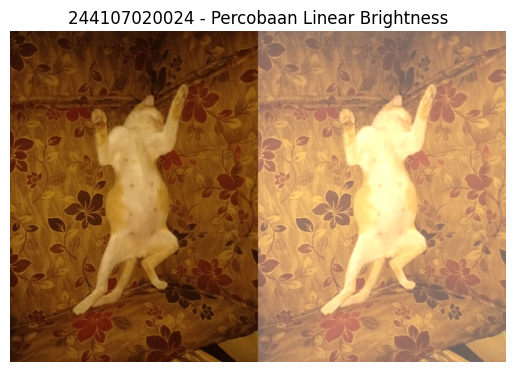

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020024"

print('-------------------------------------------')
print('      Mengubah tingkat kecerahan citra     ')
print('-------------------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0

original = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/OBJ1.jpeg')

brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])

plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Percobaan Linear Brightness")
plt.axis('off')
plt.show()

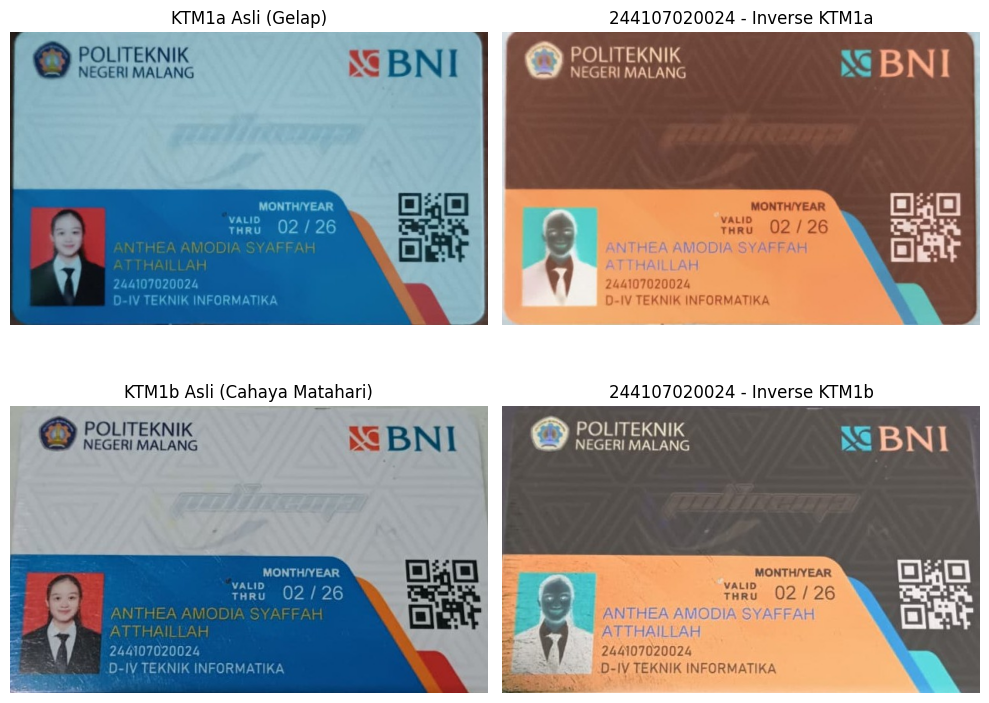

'\nPenjelasan:\nKTM1a diambil di ruangan gelap, jadi intensitasnya rendah mendekati 0 sampai hitam. Ketika di-inverse menggunakan rumus $g(x)=255-f(x)$, nilai-nilai rendah ini dibalik jadi sangat tinggi (mendekati 255 atau putih), jadi secara keseluruhan citra berubah menjadi sangat terang, pucat, sampai kehilangan detailnya.\nSedangkan KTM1b diambil menggunakan cahaya matahari yang cukup, jadi sebaran entang piksel yang gelap dan terang merata. saat diinvers proporsi perbedaan warna tetap merata dan masih terlihat detail seperti gambar aslinya.\n'

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg'
path_ktm1b = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1b.jpeg'

img_ktm1a = cv.imread(path_ktm1a)
img_ktm1b = cv.imread(path_ktm1b)

if img_ktm1a is None or img_ktm1b is None:
    print("Error: Citra tidak ditemukan. Pastikan nama dan lokasi file sesuai.")
else:
    # Konversibyaa
    img_ktm1a = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)
    img_ktm1b = cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB)

    # Operasi Inverse: 255 - nilai piksel asli
    inv_ktm1a = 255 - img_ktm1a
    inv_ktm1b = 255 - img_ktm1b

    # Menyiapkan plot 2 baris, 2 kolom
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

    # Baris 1: KTM1a
    ax[0, 0].imshow(img_ktm1a)
    ax[0, 0].set_title("KTM1a Asli (Gelap)")
    ax[0, 0].axis('off')

    ax[0, 1].imshow(inv_ktm1a)
    ax[0, 1].set_title(f"{NIM} - Inverse KTM1a")
    ax[0, 1].axis('off')

    # Baris 2: KTM1b
    ax[1, 0].imshow(img_ktm1b)
    ax[1, 0].set_title("KTM1b Asli (Cahaya Matahari)")
    ax[1, 0].axis('off')

    ax[1, 1].imshow(inv_ktm1b)
    ax[1, 1].set_title(f"{NIM} - Inverse KTM1b")
    ax[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

'''
Penjelasan:
KTM1a diambil di ruangan gelap, jadi intensitasnya rendah mendekati 0 sampai hitam. Ketika di-inverse menggunakan rumus $g(x)=255-f(x)$, nilai-nilai rendah ini dibalik jadi sangat tinggi (mendekati 255 atau putih), jadi secara keseluruhan citra berubah menjadi sangat terang, pucat, sampai kehilangan detailnya.
Sedangkan KTM1b diambil menggunakan cahaya matahari yang cukup, jadi sebaran entang piksel yang gelap dan terang merata. saat diinvers proporsi perbedaan warna tetap merata dan masih terlihat detail seperti gambar aslinya.
'''

-------------------------------------------
 Mengubah kontras dan tingkat kecerahan citra 
-------------------------------------------
Masukkan tingkat kecerahan (b): 30
Masukkan kontras (a)  : 1.6


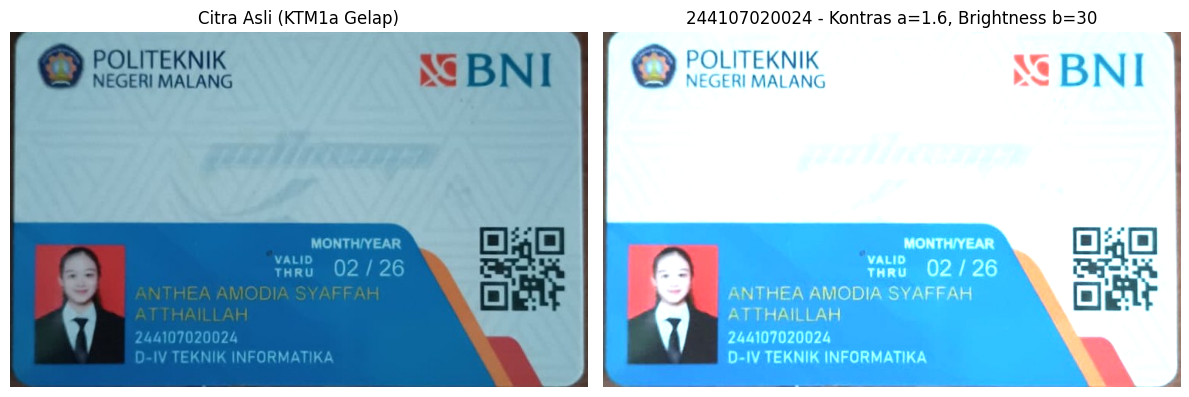

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Asumsi Anda telah menjalankan Sel Identitas sebelumnya
# NIM = "244107020024", maka N = 24
N = int(NIM[-3:])
a = round(1.0 + (N % 9) / 10, 1)

print('-------------------------------------------')
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('-------------------------------------------')

try:
    b = int(input('Masukkan tingkat kecerahan (b): '))
except ValueError:
    print('Error, not a number, defaulting to 10')
    b = 10

print(f"Masukkan kontras (a)  : {a}")

path_ktm1a = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg'
img_ktm1a = cv.imread(path_ktm1a)

if img_ktm1a is not None:
    img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

    # Fungsi cv.convertScaleAbs mengimplementasikan g(x,y) = a*f(x,y) + b
    # alpha merepresentasikan 'a' (kontras) dan beta merepresentasikan 'b' (brightness)
    # Fungsi ini juga secara otomatis menangani truncate/saturasi agar tidak error di luar 0-255
    contrast_img = cv.convertScaleAbs(img_ktm1a_rgb, alpha=a, beta=b)

    # Menampilkan hasil
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(img_ktm1a_rgb)
    ax[0].set_title("Citra Asli (KTM1a Gelap)")
    ax[0].axis('off')

    ax[1].imshow(contrast_img)
    ax[1].set_title(f"{NIM} - Kontras a={a}, Brightness b={b}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Citra KTM1a.jpeg tidak ditemukan!")

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')
try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

img_ktm1a = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg')

if img_ktm1a is not None:
    img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

    img_float = img_ktm1a_rgb.astype(np.float32)
    log_img = c * np.log(1 + img_float)

    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    final_frame = cv.hconcat([img_ktm1a_rgb, log_img])

    plt.imshow(final_frame)
    plt.axis('off')
    plt.show()
else:
    print("Citra tidak ditemukan.")

    '''
    penjelasan:
    metode clipping: Pada transformasi linier, nilai brightness ditambahkan secara merata ke setiap piksel sehingga beberapa piksel bisa melebihi batas 255. Akibatnya, area tersebut menjadi putih penuh dan kehilangan detail. Sedangkan transformasi logaritma lebih mengurangi clipping karena peningkatan kecerahannya lebih bertahap.
    '''

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_ktm1c = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1c.jpeg')

if img_ktm1c is not None:
    img_rgb = cv.cvtColor(img_ktm1c, cv.COLOR_BGR2RGB)

    R = img_rgb[:,:,0].astype(np.float32)
    G = img_rgb[:,:,1].astype(np.float32)
    B = img_rgb[:,:,2].astype(np.float32)

    # 1. Averaging
    avg_gray = np.round((R + G + B) / 3).astype(np.uint8)

    # 2. Lightness
    R_G_B_max = np.max(img_rgb, axis=2).astype(np.float32)
    R_G_B_min = np.min(img_rgb, axis=2).astype(np.float32)
    lightness_gray = np.round((R_G_B_max + R_G_B_min) / 2).astype(np.uint8)

    # 3. Luminance
    lum_gray = np.round(0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    # a. Averaging Plot
    print("a. Averaging")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(avg_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # b. Lightness Plot
    print("b. Lightness")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(lightness_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # c. Luminance Plot
    print("c. Luminance")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(lum_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # Tabel Rata-rata dan Simpangan Baku
    print("\n---------------------------------------------------------")
    print(f"{'Metode':<15} | {'Rata-rata':<15} | {'Simpangan Baku':<15}")
    print("---------------------------------------------------------")
    print(f"{'Averaging':<15} | {np.mean(avg_gray):<15.2f} | {np.std(avg_gray):<15.2f}")
    print(f"{'Lightness':<15} | {np.mean(lightness_gray):<15.2f} | {np.std(lightness_gray):<15.2f}")
    print(f"{'Luminance':<15} | {np.mean(lum_gray):<15.2f} | {np.std(lum_gray):<15.2f}")
    print("---------------------------------------------------------")

    print("\nKesimpulan:")
    print("Metode Luminance umumnya memberikan pemisahan paling jelas antara teks dan latar")
    print("kartu karena bobot warnanya (terutama hijau) disesuaikan dengan tingkat sensitivitas mata manusia.")
else:
    print("Citra tidak ditemukan.")

In [ ]:
import numpy as np
from math import log10, sqrt

def PNSR(img1, img2):
  img1 = img1.astype(np.float64)
  img1 = img2.astype(np.float64)
  if mse == 0:
    return float('inf')
  return 20 * log10(255.0 / sqrt(mse))

In [ ]:
print('-------------------------------------------------')
print('          Gamma Correction pada citra            ')
print('-------------------------------------------------')
try:
    gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

-------------------------------------------------
          Gamma Correction pada citra            
-------------------------------------------------
Masukkan nilai Gamma: 34


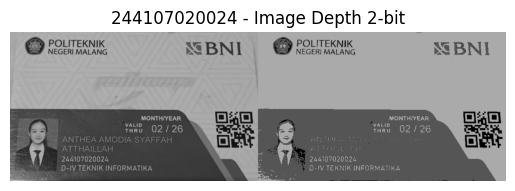

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = PARAM['bit']
level = 255 / (pow(2, bit_depth) - 1)

BASE = '/content/drive/MyDrive'
original = cv.imread(BASE + '/pcvk_3/images/244107020024/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

final_frame = cv.hconcat([original, depth_image])
final_frame_rgb = cv.cvtColor(final_frame, cv.COLOR_GRAY2RGB)

plt.imshow(final_frame_rgb)
plt.title(f"{NIM} - Image Depth {bit_depth}-bit")
plt.axis('off')
plt.show()

In [ ]:
import glob
cv_img = []
for img in glob.glob('/content/drive/MyDrive/pcvk_3/images/244107020024/OBJ1.jpeg'):
  n = cv.imread(img)
  cv_img.append(n)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

NIM = '244107020024'
FOLDER = f'/content/drive/MyDrive/pcvk_3/images/{244107020024}'

img_original = cv.imread(FOLDER + '/OBJ1.jpeg')

if img_original is None:
    raise FileNotFoundError("Gambar OBJ1.jpeg tidak ditemukan!")

cv_img = []
for img_path in sorted(glob.glob(FOLDER + '/OBJ1*.jpeg')):
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

if len(cv_img) == 0:
    raise FileNotFoundError("Tidak ada citra yang cocok dengan pola OBJ*.jpeg")

N = min(10, len(cv_img))
selected_images = cv_img[:N]

avg_img = np.zeros_like(selected_images[0], dtype=np.float64)
for img in selected_images:
    avg_img += img.astype(np.float64)

avg_img = avg_img / N
img_denoised = avg_img.astype(np.uint8)

nilai_psnr = PSNR(img_original, img_denoised)
print(f"Nilai PSNR untuk {N} citra = {nilai_psnr:.2f} dB")

img_denoised_rgb = cv.cvtColor(img_denoised, cv.COLOR_BGR2RGB)
plt.imshow(img_denoised_rgb)
plt.title(f"{NIM} - Average {N} Citra (PSNR: {nilai_psnr:.2f})")
plt.axis('off')
plt.show()

IndexError: list index out of range

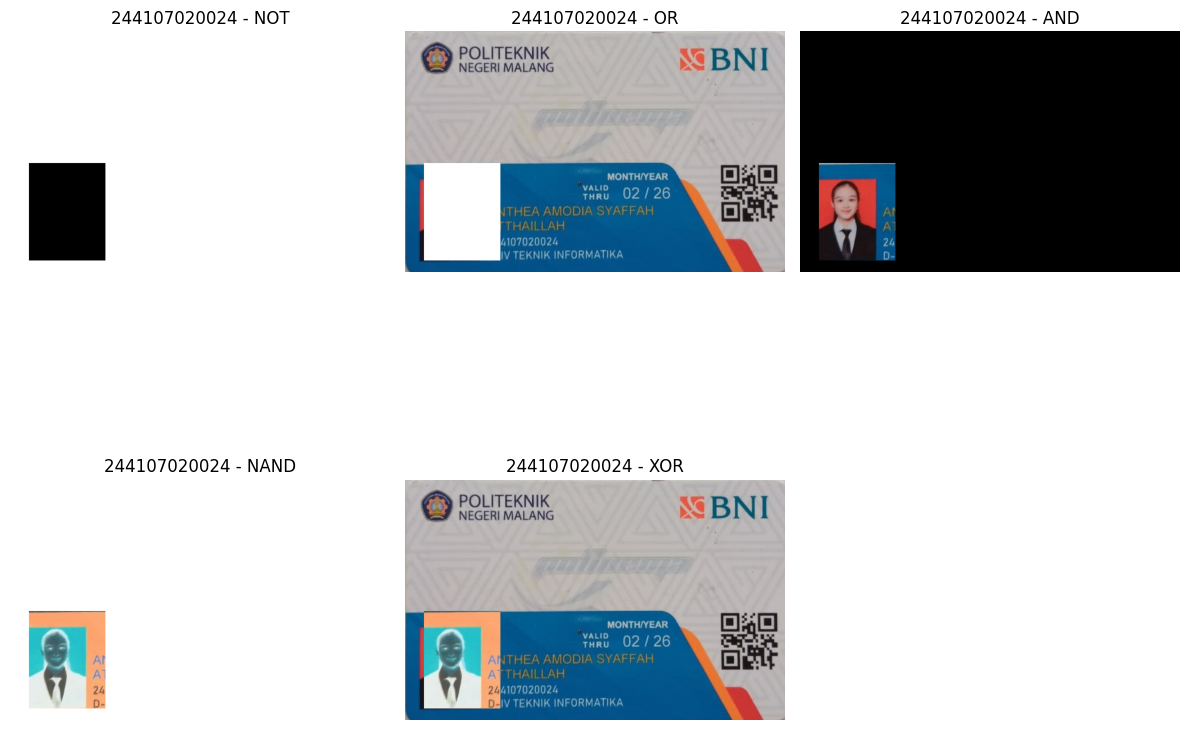

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/pcvk_3/images/244107020024'
img = cv.imread(BASE + '/KTM1d.jpeg')

if img is None:
    raise FileNotFoundError("Gambar KTM1d.jpeg tidak ditemukan!")

h, w = img.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)
cv.rectangle(mask, (int(w*0.05), int(h*0.55)), (int(w*0.25), int(h*0.95)), 255, -1)
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

res_not = cv.bitwise_not(mask_3ch)
res_or = cv.bitwise_or(img, mask_3ch)
res_and = cv.bitwise_and(img, mask_3ch)
res_nand = cv.bitwise_not(res_and)
res_xor = cv.bitwise_xor(img, mask_3ch)

outputs = [res_not, res_or, res_and, res_nand, res_xor]
titles = [f"{NIM} - NOT", f"{NIM} - OR", f"{NIM} - AND", f"{NIM} - NAND", f"{NIM} - XOR"]

plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(outputs[i], cv.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()